In [25]:
import numpy as np
import matplotlib.pyplot as plt
import datasets

In [26]:
mnist_ds = datasets.load_from_disk("ylecun/mnist").with_format("numpy")

# 2. Extract contiguous blocks directly (instant PyArrow extraction)
X_train = (mnist_ds["train"]["image"][:] / 255.0).astype(np.float32)
y_train = mnist_ds["train"]["label"][:].astype(np.int64)

X_test = (mnist_ds["test"]["image"][:] / 255.0).astype(np.float32)
y_test = mnist_ds["test"]["label"][:].astype(np.int64)

# 3. Fast in-memory shuffle using NumPy
rng = np.random.default_rng(42)

train_idx = rng.permutation(len(X_train))
X_train, y_train = X_train[train_idx], y_train[train_idx]

test_idx = rng.permutation(len(X_test))
X_test, y_test = X_test[test_idx], y_test[test_idx]

4


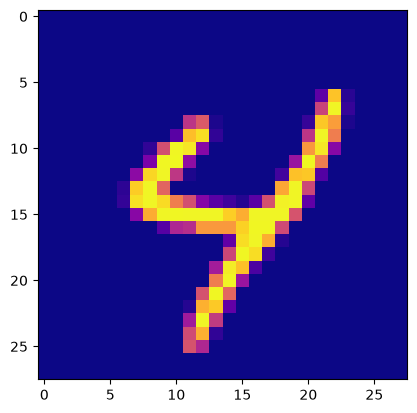

In [27]:
plt.imshow(X_train[96], cmap="plasma", interpolation="None")
print(y_train[96])

In [ ]:
from abc import ABC, abstractmethod
from typing import Iterator
from numpy.typing import NDArray

class Model(ABC):

    layers: list

    @abstractmethod
    def accumulate_gradients(self, gradients_forward): pass
    
    def zero_grad(self):
        for layer in self.layers: layer.zero_grad()

    @abstractmethod
    def __call__(self, x): pass

    @abstractmethod
    def parameters(self) -> Iterator[tuple[NDArray[np.float32], NDArray[np.float32]]]: pass

    
class Optimizer(ABC):
    
    @abstractmethod
    def step_accumulate_gradients(self, x, y): pass

    @abstractmethod
    def step_learn(self): pass



class Layer():
    def __init__(self, nin, nout, nonlin, seed=42): # eah nout is a neuron
        self._tmp = np.zeros((nout, nin), dtype=np.float32) # used as a buffer to avoid reallocating constantly
        self.nout = nout
        self.nin = nin
        rng = np.random.default_rng(seed)

        self.weights = rng.standard_normal((nout, nin), dtype=np.float32) * np.float32(np.sqrt(2.0 / nin)) 
        self.gradients = np.zeros((nout, nin), dtype=np.float32)

        self.bias_weights = rng.standard_normal((nout,), dtype=np.float32) * np.float32(np.sqrt(2.0 / nin)) 
        self.bias_gradients = np.zeros((nout,), dtype=np.float32)

        self.mask = np.ones((nout,), dtype=np.float32)
        self.nonlin = nonlin
        self.activationsin = np.zeros((nin,), dtype=np.float32)
        self.activationsout = np.zeros((nout,), dtype=np.float32)
        

    def __call__(self, activation):
        self.activationsin = activation
        neurons_out = (self.weights @ activation) + self.bias_weights
        if self.nonlin:
            self.mask = neurons_out > 0 # ReLu activation function
        self.activationsout = neurons_out * self.mask
        return self.activationsout
    
    def accumulate_gradients(self, gradients_forward):
        # gradients_forward is of shape [nout]
        # self.gradients is of shape [nout, nin]
        # self.activationsin of shape [nin] -> [nout, nin]

        gradients_forward = gradients_forward * self.mask # kills gradients of dead neurons

        weight_activationsin = np.broadcast_to(self.activationsin, (self.nout, self.nin)) # each weight contains a matching activation
        weight_forward_gradients = np.broadcast_to(gradients_forward[:, np.newaxis], (self.nout, self.nin))

        # a weights local derivative is its corresponding input then we multiply to chain it to/ by the upstream derivative
        np.multiply(weight_activationsin, weight_forward_gradients, out=self._tmp)
        self.gradients += self._tmp

        # bias gradient have a local derivative thats always 1 so we only chain to upstream derivative
        self.bias_gradients += gradients_forward

        # gradient at each input, equals the sum of (each weight connected to it) multiplied by its upstream gradient (forward gradient)
        # self.weights [nout, nin + 1]   gradients_forward [nout]
        gradients_backward = gradients_forward @ self.weights
        return gradients_backward
        

    def zero_grad(self):
        self.gradients.fill(0)
        self.bias_gradients.fill(0)

    def update_weights(self, learning_rate):
        np.multiply(learning_rate, self.gradients, out=self._tmp) # weights
        
        self.weights -= self._tmp
        self.bias_weights -= self.bias_gradients * learning_rate

    def parameters(self):
        yield self.weights, self.gradients
        yield self.bias_weights, self.bias_gradients

    def __repr__(self):
        nin = self.weights.shape[1]
        nout = self.weights.shape[0]
        
        lines = [f"Layer(nin={nin}, nout={nout}, nonlin={self.nonlin}):"]
        
        # Format weights matrix and bias column
        for i in range(nout):
            # Format each weight with fixed total width (e.g., 7 chars, 3 decimals, space for sign)
            w_row = " ".join(f"{w: 7.3f}" for w in self.weights[i])
            bias = f"{self.bias_weights[i]: 7.3f}"
            mask = f"{int(self.mask[i])}"
            
            lines.append(f"  Neuron {i}: W = [{w_row} ]  b = {bias}  mask = {mask}")
            
        return "\n".join(lines)

    
class MLP(Model):
    def __init__(self, nin, nouts): # int, int[]
        self.layers = []

        # making all layers nonlin (relu) except the last

        if len(nouts) > 1: self.layers.append(Layer(nin=nin, nout=nouts[0], nonlin=True))
        else: self.layers.append(Layer(nin=nin, nout=nouts[0], nonlin=False))

        for i, width in enumerate(nouts[1:-1], start=1):
            self.layers.append(Layer(nin=nouts[i-1], nout=width, nonlin=True, seed=42 + i))

        if len(nouts) > 1: self.layers.append(Layer(nin=nouts[-2], nout=nouts[-1], nonlin=False))

    def __call__(self, activations):
        for layer in self.layers:
            activations = layer(activations)
        return activations

    def parameters(self):
        for layer in self.layers:
            yield from layer.parameters()
    
    def zero_grad(self):
        

    def accumulate_gradients(self, gradients_forward):

        for layer in reversed(self.layers):
            gradients_forward = layer.accumulate_gradients(gradients_forward=gradients_forward)

    def __repr__(self):
            out = ""
            for k, layer in enumerate(self.layers):
                out += f"Layer {k}: {str(layer)}\n\n"
            return out
    
    def stats(self):
        header = f"{'Layer':<7}{'Inputs':>10}{'Neurons':>10}{'Params':>12}  {'Activation':<10}"
        line = "-" * len(header)

        print(line)
        print(header)
        print(line)

        total = 0
        for k, layer in enumerate(self.layers):
            params = layer.nout * (layer.nin + 1)   # weights + biases
            total += params
            act = "ReLU" if layer.nonlin else "Linear"
            print(f"{k:<7}{layer.nin:>10,}{layer.nout:>10,}{params:>12,}  {act:<10}")

        print(line)
        print(f"Layers: {len(self.layers)}")
        print(f"Total parameters: {total:,}")
        print(f"Memory (weights, float32): {total * 4 / 1e6:.2f} MB")
        print(line)

class SGD(Optimizer): # Standard Gradient Decent, dumb decent
    def __init__(self, model: Model, learning_rate):
        self.model = model
        self.learning_rate = learning_rate

    def step_accumulate_gradients(self, x, y): # accumulates allowing for chunking

        z = self.model(x)
        self.model.accumulate_gradients(z_loss_gradient(z=z, y=y))

    def step_learn(self):
        for p, g in self.model.parameters():
            g *= self.learning_rate              # in place, no temp
            p -= g   
        self.model.zero_grad()

    


# TODO: optimizer, remove update_weights methods from Layer and MLP objects aswell

def z_loss_gradient(z, y): # IMPORTANT : must be at least 2 classes or else gradient is always 0
    if len(z) == 1: raise ArithmeticError("Must have at least 2 outputs or else gradients are always 0")

    exp_z = np.exp(z - np.max(z))  # Subtract max to prevent overflow
    probs = exp_z / np.sum(exp_z)  # Softmax activation
    return probs - y

def z_loss(z, y):
    z_shifted = z - np.max(z)                      # for numerical stability
    log_probs = z_shifted - np.log(np.sum(np.exp(z_shifted)))   # log-softmax
    return -np.sum(y * log_probs)
    

In [29]:
# layer = Layer(nin=10000, nout=10000, nonlin=False)
# mlp = MLP(nin=14*14, nouts=[12*12, 8*8, 10])
mlp = MLP(nin=10_000, nouts=[10_000, 10_000])

x = np.ones([10000], dtype=np.float32)
y = np.zeros([10000], dtype=np.float32)   # one-hot: class 0
y[2] = 1


In [30]:
mlp.zero_grad()

print("Forward:")
%time z = mlp(x)
z_grad = z_loss_gradient(z=z, y=y)   # now nonzero

print("Backward:")
%time mlp.accumulate_gradients(gradients_forward=z_grad)

print("Update:")
%time mlp.update_weights(learning_rate=0.05)

print(f"z loss = {z_loss(z=z, y=y)}")

Forward:
CPU times: total: 156 ms
Wall time: 17.8 ms
Backward:
CPU times: total: 531 ms
Wall time: 325 ms
Update:
CPU times: total: 0 ns
Wall time: 35.3 μs


AttributeError: 'MLP' object has no attribute 'update_weights'

## Previous:
```
CPU times: total: 78.1 ms
Wall time: 18.9 ms
CPU times: total: 312 ms
Wall time: 241 ms
z loss = 10.380485534667969
```

In [ ]:
layer.zero_grad()
z = layer(x)
z_grad = z_loss_gradient(z=z, y=y)   # now nonzero

print(f"z = {z}")
print(f"z_grad = {z_grad}")
print(f"z loss = {z_loss(z=z, y=y)}")

layer.accumulate_gradients(gradients_forward=z_grad)
layer.weights -= 0.5 * layer.gradients

z = [ 1.5557738e-01 -1.2029809e+00  4.9987564e+02 ...  5.7568538e-01
  1.3061162e+00  6.1387837e-01]
z_grad = [0. 0. 0. ... 0. 0. 0.]
z loss = -0.0


In [ ]:
z

array([ 1.5557738e-01, -1.2029809e+00,  4.9987564e+02, ...,
        5.7568538e-01,  1.3061162e+00,  6.1387837e-01],
      shape=(10000,), dtype=float32)